In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.environ["DMRGROOT"]) # add the library via environmental variable
# you have to install the dmrgpy library from
# https://github.com/joselado/dmrgpy
# and add its address to your python path (done above with an environmental variable)

# some default parameters in matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 8]
plt.rcParams['font.size'] = 22
plt.rcParams['image.cmap'] = 'coolwarm'


import numpy as np

# Matrix product states for spin chain models
In this session we will address quantum spin chains too large for exact diagonalization, and how they can be solved with matrix product states

### Contents
- System size scaling of exact diagonalization and matrix product states
- The role of the bond dimension in ground and excited states
- Entanglement entropy of many-body ground states, and its use to detect quantum phase transitions
- Large Heisenberg chains: magnetization, impurities, gaps and correlators
- Fractionalization in the S=1 Heisenberg chain

### Learning outcomes
- Solve many-body spin models with tensor networks
- Understand the role of bond dimension in tensor networks
- Understand the role of spin-spin correlators in quantum spin models

## Energy of the Heisenberg model as a function of the system size
Let us first look at the many-body energy of the Heisenberg model as function of the system size

Here we take the same spin-$1/2$ Heisenberg chain as in the previous sessions, $H_{\text{Heis}} = J\sum_n \mathbf{S}_n\cdot\mathbf{S}_{n+1}$ with open boundaries, and we compute its ground state energy per site, $E_0/N$, for chains of $N=2$ to $38$ spins, now with the density matrix renormalization group, DMRG, the algorithm that finds the ground state within the matrix product states. Everything else in the code is the same as with exact diagonalization, only the mode of the solver changes, and the sizes go well beyond what an exponentially growing Hilbert space allows. Look at how the energy per site evolves with $N$, and at whether it settles.

ITensor v3's two-site DMRG can't handle a chain this short (n=2 < 3 sites), using default ED routines


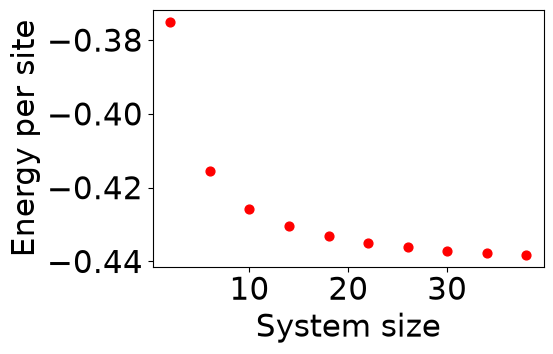

In [2]:
from dmrgpy import spinchain

def get_energy(N):
    """Return energies for a system fo size N"""
    spins = ["S=1/2" for i in range(N)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = 1. # exchange coupling
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + J*sc.Sx[i]*sc.Sx[i+1] ; h = h + J*sc.Sy[i]*sc.Sy[i+1] ; h = h + J*sc.Sz[i]*sc.Sz[i+1]
    sc.set_hamiltonian(h) # set the Hamiltonian
    return sc.gs_energy(mode="DMRG")/N # energy per site

plt.figure(figsize=(6,4))

Ns = [i for i in range(2,40,4)] # lengths of the system
es = [get_energy(N) for N in Ns] # ground state energy per site

plt.scatter(Ns,es,s=40,c="red") # plot the energies

plt.xlabel("System size") ; plt.ylabel("Energy per site") ;  plt.tight_layout()

### Quiz
- Why does the energy per site depend on the system size?
- What would be the value in the thermodynamic limit?
- What is the biggest system that you could compute with exact diagonalization?

## Near linear scaling with system size with matrix product states
We now show that matrix product states allow computing the ground state with a complexity that is linear with the system size

Here we measure the time it takes to compute the ground state with DMRG for chains of $N=10$ to $70$ spins, with the bond dimension fixed to $\chi=20$, and we plot it against $N$ on a linear scale and on a log-log scale, where a power law $t \sim N^\alpha$ becomes a straight line of slope $\alpha$. A matrix product state stores the wave function as a product of $N$ matrices of size $\chi\times\chi$, one per spin, and the time we measure is what it costs to find the ground state within this ansatz. Look at the slope in the right panel.

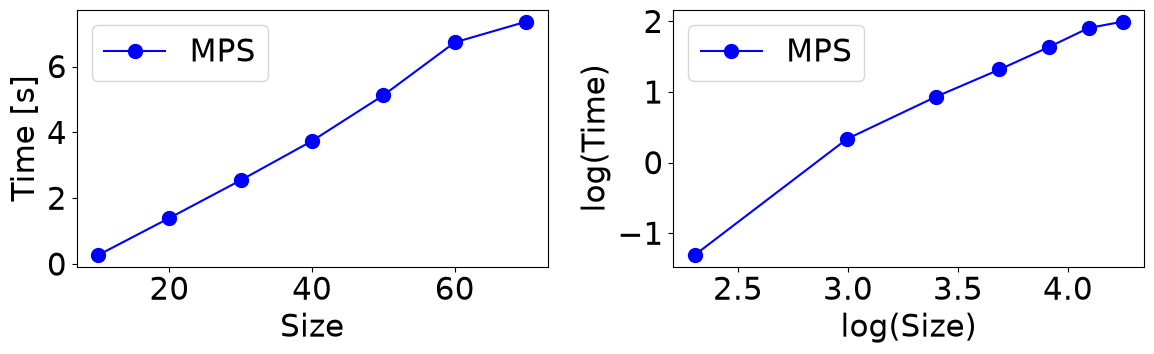

In [3]:
from dmrgpy import spinchain

def get_times(N):
    """Return time required for the calculation with MPS"""
    spins = ["S=1/2" for i in range(N)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = 1. # exchange coupling
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + J*sc.Sx[i]*sc.Sx[i+1] ; h = h + J*sc.Sy[i]*sc.Sy[i+1] ; h = h + J*sc.Sz[i]*sc.Sz[i+1]
    import time
    sc.set_hamiltonian(h) # set the Hamiltonian
    t0mps = time.time() # initial time for MPS
    sc.maxm = 20 # not large bond dimension
    sc.get_gs(mode="DMRG") # compute ground state
    t1mps = time.time() # final time for MPS
    return t1mps-t0mps # return MPS times

plt.figure(figsize=(12,4))

Ns = [i for i in range(10,80,10)] # lengths of the system
tsmps = [get_times(N) for N in Ns] # computational times

plt.subplot(1,2,1)
plt.plot(Ns,tsmps,markersize=10,c="blue",label="MPS",marker="o") # plot the MPS times
plt.xlabel("Size") ; plt.ylabel("Time [s]")
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.log(Ns),np.log(tsmps),markersize=10,c="blue",label="MPS",marker="o") # plot the MPS times
plt.xlabel("log(Size)") ; plt.ylabel("log(Time)")
plt.legend()

plt.tight_layout()

### Quiz
- Why is the scaling linear with the system size if the Hilbert space has exponential dimension?
- How can you know that the ground state you got is accurate, and can you quantify this somehow?

## The role of the bond dimension
We will now see that the bond dimension control the accuracy of the calculation, by computing the fluctuation of the energy per site

The bond dimension is the size of the matrices in the matrix product state, so it sets how many parameters the variational state has. Here we take a chain of 20 spins and we compute its ground state with DMRG for bond dimensions $\chi$ from $3$ to $23$, storing for each one the energy per site and the energy fluctuation per site, $\Delta E = \sqrt{\langle\Omega|H^2|\Omega\rangle - \langle\Omega|H|\Omega\rangle^2}$, where $|\Omega\rangle$ is the variational state the algorithm returns. Look at how both panels evolve with $\chi$, and at whether they stop changing at some point.

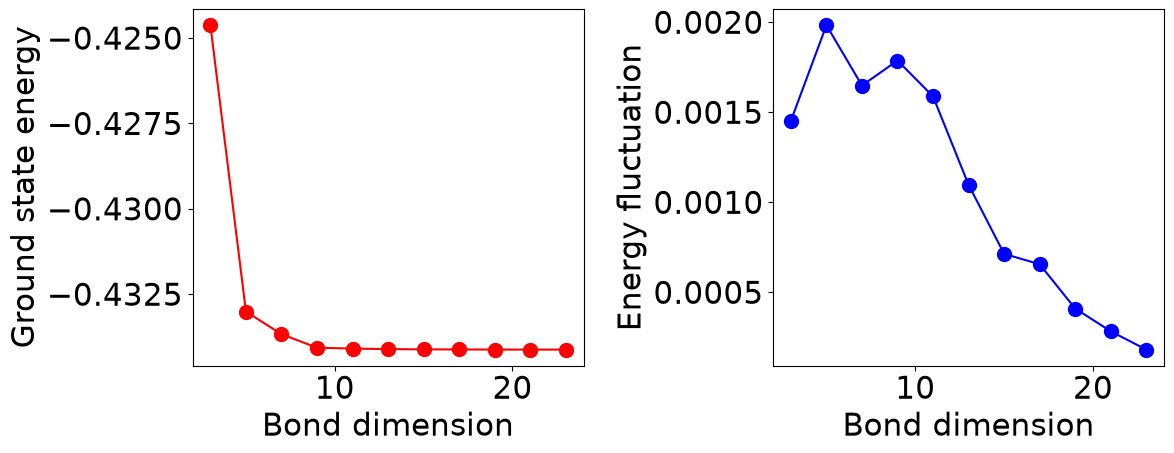

In [4]:
from dmrgpy import spinchain
import numpy as np
n= 20 # size of the chain
spins = ["S=1/2" for i in range(n)] # S=1/2 chain
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
for i in range(len(spins)-1):
    h = h + sc.Sx[i]*sc.Sx[i+1]
    h = h + sc.Sy[i]*sc.Sy[i+1]
    h = h + sc.Sz[i]*sc.Sz[i+1]
bds = range(3,24,2) # bond dimension
es,des = [],[] # storage of energies and fluctuations
for maxm in bds: # loop over bond dimension
    sc.set_hamiltonian(h) # create the Hamiltonian
    sc.maxm = maxm # set the bond dimension
    e = sc.gs_energy() # get the ground state energy
    wf = sc.get_gs() ; de = wf.dot(h*(h*wf)) # <H^2>, needed for the energy fluctuation
    de = np.sqrt(np.abs(de-e**2)) # energy fluctuation
    es.append(e/n) # store energy
    des.append(de/n) # energy fluctuation
    
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(bds,es,c="red",marker="o",markersize=10)
plt.ylabel("Ground state energy")
plt.xlabel("Bond dimension")

plt.subplot(1,2,2)
plt.plot(bds,des,c="blue",marker="o",markersize=10)
plt.ylabel("Energy fluctuation")
plt.xlabel("Bond dimension")

plt.tight_layout()
plt.show()

### Quiz
- Which value of the bond dimension is enough to get an accurate ground state?
- What does it mean, the energy fluctuation of the ground state?
- Make the system bigger, how do the previous plots behave, and why?

## The role of bond dimension in excited states
Let us now look at how excited states depend on the bond dimension of the matrix product state

Now we do the same for the eight lowest eigenstates $|\Omega_k\rangle$ of a chain of 14 spins, computing for each of them and for each bond dimension from $2$ to $9$ the energy and the energy fluctuation, $\Delta E_k = \sqrt{\langle\Omega_k|H^2|\Omega_k\rangle - \langle\Omega_k|H|\Omega_k\rangle^2}$, which we plot on a logarithmic scale. Excited states are found one after the other, each one constrained to be orthogonal to the states already computed. Look at how the curves of the different states are ordered in both panels.

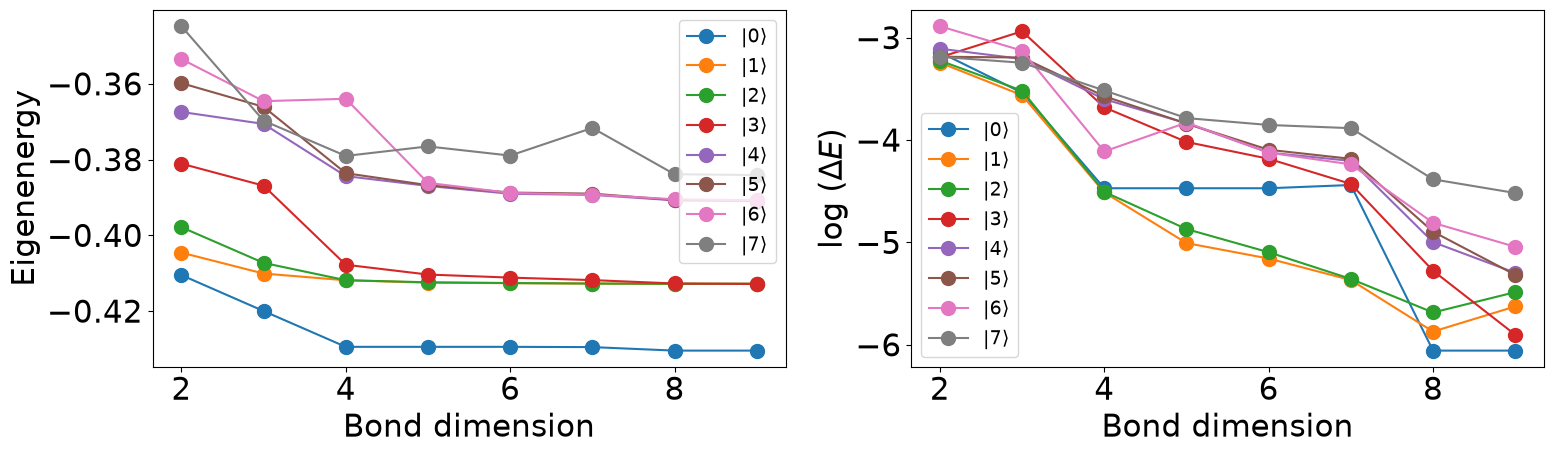

In [5]:
from dmrgpy import spinchain
import numpy as np
n= 14 # size of the chain
spins = ["S=1/2" for i in range(n)] # S=1/2 chain
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
for i in range(len(spins)-1):
    h = h + sc.Sx[i]*sc.Sx[i+1]
    h = h + sc.Sy[i]*sc.Sy[i+1]
    h = h + sc.Sz[i]*sc.Sz[i+1]

h2 = sc.toMPO(h)*sc.toMPO(h) # Hamiltonian square (to compute expectation values)
bds = range(2,10) # bond dimension
es,des = [],[] # storage of energies and fluctuations
for maxm in bds: # loop over bond dimension
    sc.set_hamiltonian(h) # create the Hamiltonian
    sc.maxm = maxm # set the bond dimension
    nex = 8 # number of excited states
    exs,wfs = sc.get_excited_states(mode="DMRG",n=nex,purify=False) # compute excited states
    esi,desi = [],[] # storage
    for (e,wf) in zip(exs,wfs): # loop over excited states
        e = wf.aMb(h,wf) # explicit energy
        de = wf.aMb(h2,wf) # <H^2>, needed for the energy fluctuation
        de = np.sqrt(np.abs(de-e**2)) # energy fluctuation
        esi.append(e/n) # store energy
        desi.append(de/n) # energy fluctuation
    es.append(esi) # store energy
    des.append(desi) # store fluctuation

es = np.array(es) ; des = np.array(des) # to arrays

plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
for i in range(nex): # loop over excited states
    plt.plot(bds,es[:,i],marker="o",markersize=10,label="|"+str(i)+"$\\rangle$")

plt.legend(fontsize=14)
plt.ylabel("Eigenenergy")
plt.xlabel("Bond dimension")

plt.subplot(1,2,2)
for i in range(nex): # loop over excited states
    plt.plot(bds,np.log(des[:,i]),marker="o",markersize=10,label="|"+str(i)+"$\\rangle$")

plt.legend(fontsize=14)
plt.ylabel("log ($\\Delta E$)")
plt.xlabel("Bond dimension")

plt.tight_layout()


### Quiz
- Which states converge faster with the bond dimension, and why?
- Which plot is most informative to know how converged the states are?
- Add a magnetic field to the Hamiltonian, do the plots qualitatively change, and why?

## Low energy excitations of a Heisenberg model
We will now see what are the matrix elements between the ground state and the first excited state in a Heisenberg model

Here we take a chain of 20 spins with a small field $B_z = 0.03J$, we compute the ground state $|0\rangle$ and the first excited state $|1\rangle$ with DMRG, and we plot the absolute value of the matrix element $\langle 1|S_n^x|0\rangle$ as a function of the site $n$ on which the spin operator acts. A matrix element like this one enters any transition rate between the two states, for instance under an oscillating field, and it asks on which sites acting with $S^x$ connects one state to the other. Look at how the profile depends on the position along the chain.

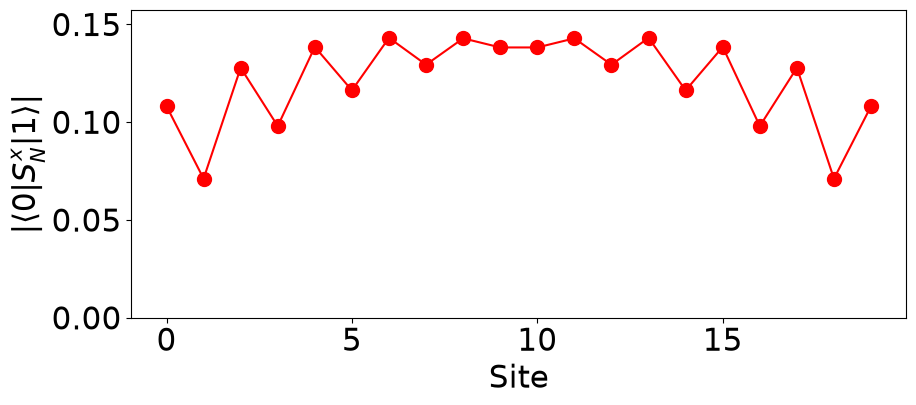

In [6]:
from dmrgpy import spinchain

L = 20 # number of spins
spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
for i in range(len(spins)-1): # Heisenberg coupling
    h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
Bz = 0.03 # small magnetic field
for i in range(len(spins)): h = h + Bz*sc.Sz[i] # and let's add a small magnetic field
sc.set_hamiltonian(h) # set the Hamiltonian

es,wfs = sc.get_excited_states(mode="DMRG",n=2)
wf0,wf1 = wfs[0],wfs[1] # lowest and first excited state


cs = [wf1.dot(sc.Sx[i]*wf0) for i in range(L)] # matrix elements between ground state and excited state

plt.figure(figsize=(10,4))
plt.plot(range(L),np.abs(cs),markersize=10,c="red",marker="o")
plt.xlabel("Site") ; plt.ylabel("$|\\langle 0|S^x_N|1\\rangle |$")
plt.ylim([0,max(np.abs(cs))*1.1])
plt.show()

### Quiz
- What is the physical interpretation of the previous profile?
- Why does the profile have a minimum at the edges and a maximum at the center?
- Make the system smaller, what happens?

## Level crossings as a function of the magnetic field with matrix product states
We will now show that as an external magnetic field is included, level crossings in the system take place leading to different ground states

Here we repeat with matrix product states the calculation we did with exact diagonalization for eight spins in the second session, now for a chain of 20 spins: we add a uniform field, $H = J\sum_n \mathbf{S}_n\cdot\mathbf{S}_{n+1} + B\sum_n S_n^z$, and for each value of $B$ between $-2J$ and $2J$ we compute the ground state and its magnetization on every site, shown as a color map. With more spins there are more values the total magnetization can take, so there are more ground states to go through as the field grows. Compare this map with the one you obtained for eight spins.

Text(0, 0.5, '$B_z$')

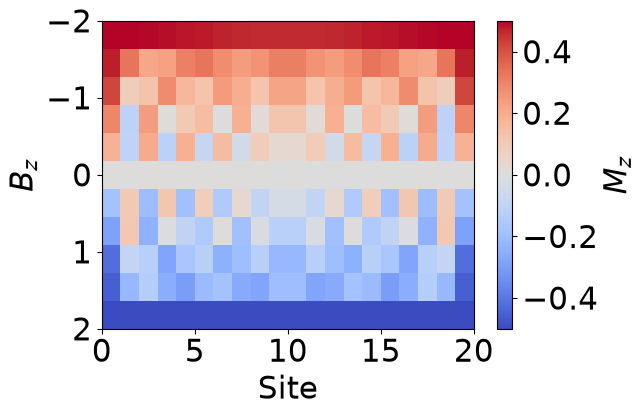

In [7]:
from dmrgpy import spinchain

L = 20 # number of spins

def get_mz(Bz):
    spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
    h = h + Bz*sum(sc.Sz) # add external field
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG")
    return [wf0.dot(Szi*wf0).real for Szi in sc.Sz] # magnetization in each site



Bzs = np.linspace(-2.,2.,11,endpoint=True) # magnetic fields
Mzs = [get_mz(Bz) for Bz in Bzs] # compute magnetizations

plt.figure(figsize=(6,4))

plt.imshow(Mzs,aspect="auto",extent=[0,L,max(Bzs),min(Bzs)],vmin=-0.5,vmax=0.5) # diverging quantity, use the notebook's default coolwarm colormap
plt.colorbar(label="$M_z$") ; plt.xlabel("Site") ; plt.ylabel("$B_z$")

### Quiz
- Why does the magnetization saturate at high magnetic fields?
- Make the system smaller, what do you observe and why?

## Entanglement entropy of the ground state
We will now see how the entanglement entropy in each bond of the variational state depends on the bond dimension

Cutting the chain at a bond splits it into a left part $A$ and a right part $B$, and the entanglement entropy across that bond is the von Neumann entropy of the reduced density matrix of one of them, $S_A \equiv -\text{Tr}\left[\rho_A \ln \rho_A\right]$ with $\rho_A \equiv \text{Tr}_B\rho$, which in a matrix product state is read directly from the matrices at that bond. Here we take a chain of 20 spins, we compute its ground state with DMRG for $\chi = 2$, $4$, $8$ and $20$, and we plot the entropy of every bond. Look at the shape of the profile along the chain and at how it changes with $\chi$.

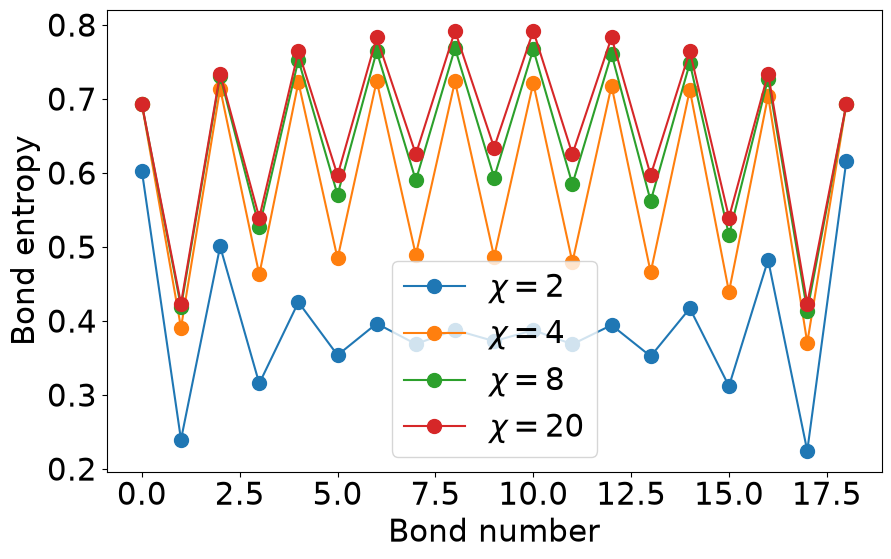

In [8]:
from dmrgpy import spinchain

def get_bond_entropies(maxm):
    L = 20 # 20 spins
    spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
    sc.maxm = maxm # set the bond dimension
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG")
    return [wf0.get_bond_entropy(i-1,i) for i in range(1,L)]

plt.figure(figsize=(10,6))

for maxm in [2,4,8,20]:
    cs = get_bond_entropies(maxm) # bond entropies for this bond dimension
    plt.plot(range(len(cs)),cs,markersize=10,marker="o",label="$\chi = $"+str(maxm))
    plt.xlabel("Bond number") ; plt.ylabel("Bond entropy")

plt.legend()

### Quiz
- Why does the entanglement entropy saturate with the bond dimension?
- Make the system bigger, how does the previous plot change, and why?
- What is the meaning of the bond entanglement entropy?
- Replace the Heisenberg model by an Ising model, how does the entanglement entropy change, and why?

## Size dependence of the entanglement entropy
We will now see that for a one dimensional system the entanglement entropy has a weak system size dependence

As a reference, think of what would happen for a generic state of the Hilbert space: each half of the chain has an exponentially large number of states available, and the entropy of a random state would grow in proportion to the number of spins in the half chain. Here we compute the entanglement entropy at the central bond of the Heisenberg chain, splitting it into two halves, for chain lengths from $L=10$ to $48$, and we plot it against $L$. Look at the scale of the vertical axis and at the shape of the curve.

(0.0, 0.9769446773426509)

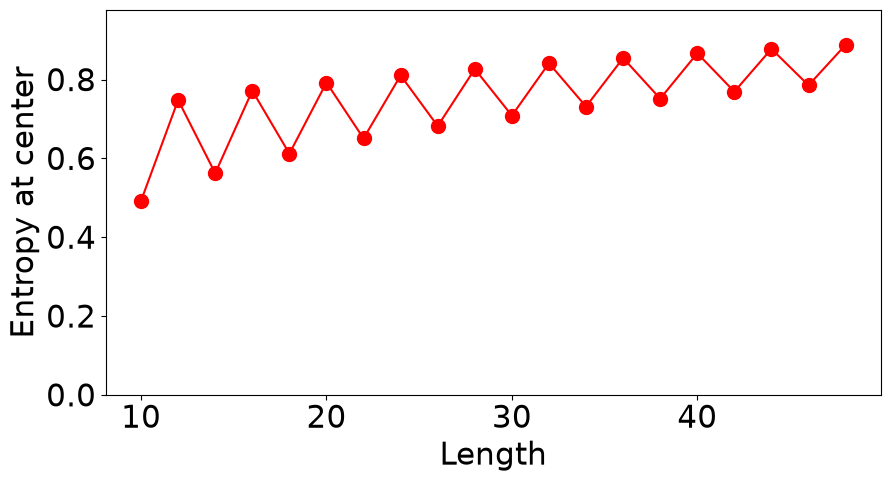

In [9]:
from dmrgpy import spinchain

def get_entropy(L=20):
    spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG") # get ground state
    return wf0.get_bond_entropy(L//2,L//2+1)

Ls = range(10,50,2) # lengths
Ss = [get_entropy(L=L) for L in Ls] # entropies

plt.figure(figsize=(10,5))
plt.plot(Ls,Ss,markersize=10,marker="o",c="red")
plt.xlabel("Length") ; plt.ylabel("Entropy at center") ; plt.ylim([0,max(Ss)*1.1])



### Quiz
- Why does the entanglement entropy grow so slowly?
- Could you modify the Hamiltonian so that the growth is even slower, and if so, how?

## Open and closed boundary conditions
Let us now see which type of boundary condition creates more entropy

Keep in mind that a matrix product state is always a chain of matrices with a beginning and an end, regardless of the Hamiltonian. Here we compute the entanglement entropy at the central bond for chains of $L=4$ to $18$ spins, once with open boundaries and once with an additional coupling between the first and the last spin, which turns the chain into a ring, represented with the very same ansatz. Look at which of the two curves lies higher, and by roughly how much.

(0.0, 1.4412440701910254)

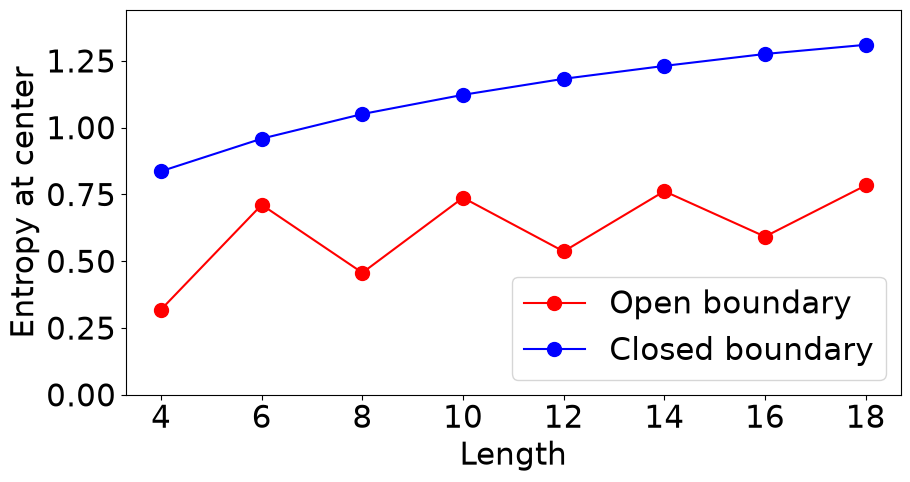

In [10]:
from dmrgpy import spinchain

def get_entropy(L=20,closed=True):
    spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
    if closed: # if closed boundary conditions
        h = h + sc.Sx[0]*sc.Sx[L-1] ; h = h + sc.Sy[0]*sc.Sy[L-1] ; h = h + sc.Sz[0]*sc.Sz[L-1]
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG") # get ground state
    return wf0.get_bond_entropy(L//2-1,L//2)

Ls = range(4,20,2) # lengths
Ss_open = [get_entropy(L=L,closed=False) for L in Ls] # entropies
Ss_closed = [get_entropy(L=L,closed=True) for L in Ls] # entropies

plt.figure(figsize=(10,5))
plt.plot(Ls,Ss_open,markersize=10,marker="o",c="red",label="Open boundary")
plt.plot(Ls,Ss_closed,markersize=10,marker="o",c="blue",label="Closed boundary")
plt.legend()
plt.xlabel("Length") ; plt.ylabel("Entropy at center") 
plt.ylim([0,max(Ss_closed)*1.1])

### Quiz
- Which choice is more demanding from a computational point of view?
- If you remove one of the couplings in the middle of the chain, is it the same as removing the first to last? Why?
- Remove the XX and YY couplings, what has changed, and why?

## Bond dimension dependence of the entanglement entropy
We will now see how the entanglement entropy of a many-body state depends on the bond dimension of the matrix product state

Here we compute the entanglement entropy at the central bond as a function of the bond dimension, from $\chi=1$ to $19$, for two chains, one with $L=10$ and one with $L=30$ spins. Remember two things from the exercises above: the true entropy of the ground state grows with $L$, and the bond dimension sets how many parameters the variational state has at each bond. Look at where each curve flattens, and compare the two chains at $\chi=5$.

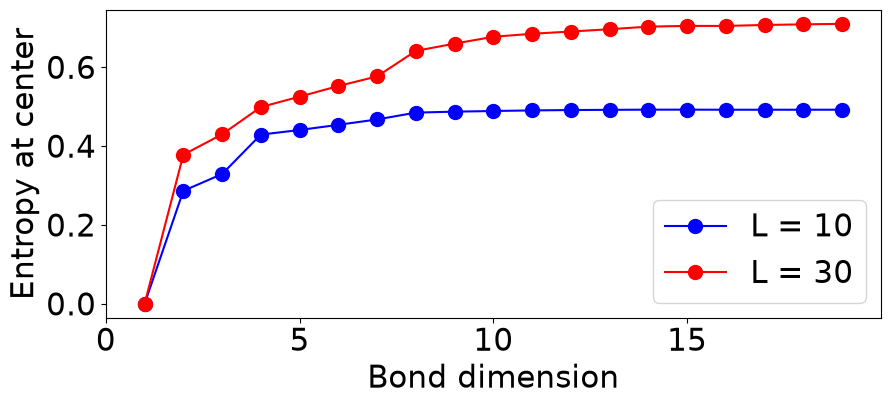

In [11]:
from dmrgpy import spinchain

def get_entropy(maxm=10,L=10):
    spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
    sc.set_hamiltonian(h) # set the Hamiltonian
    sc.maxm = maxm
    wf0 = sc.get_gs(mode="DMRG") # get ground state
    return wf0.get_bond_entropy(L//2,L//2+1)

ms = range(1,20,1) # bond dimensions
Ss0 = [get_entropy(maxm=m,L=10) for m in ms] # entropies
Ss1 = [get_entropy(maxm=m,L=30) for m in ms] # entropies

plt.figure(figsize=(10,4))
plt.plot(ms,Ss0,markersize=10,marker="o",c="blue",label="L = 10")
plt.plot(ms,Ss1,markersize=10,marker="o",c="red",label="L = 30")
plt.xlabel("Bond dimension") ; plt.ylabel("Entropy at center") ; plt.xlim([0,20]) ; plt.xticks(range(0,20,5))
plt.legend()


### Quiz
- Which ground state is more accurate at bond dimension 5?
- Make the system bigger, when does the entropy saturate and why?
- Remove the XX and YY couplings, what happens and why?

## The entanglement entropy as a signal for phase transitions
Let us now see that the entanglement entropy can be used to detect a quantum phase transition, in particular for the transverse field Ising model

Here we take the transverse field Ising model, $H_{\text{TFI}} = -J\sum_n S_n^zS_{n+1}^z + B_x\sum_n S_n^x$ with $J=1$, a ferromagnetic Ising coupling along $z$ competing with a field along $x$ that does not commute with it, and for a chain of 40 spins we compute the entanglement entropy at the central bond as a function of $B_x$ between $0$ and $J$. The ground state is computed starting from the fully polarized state along $z$, which helps the algorithm at small fields. Look at where along the horizontal axis the entropy is largest, and at what it does far from that point on either side.

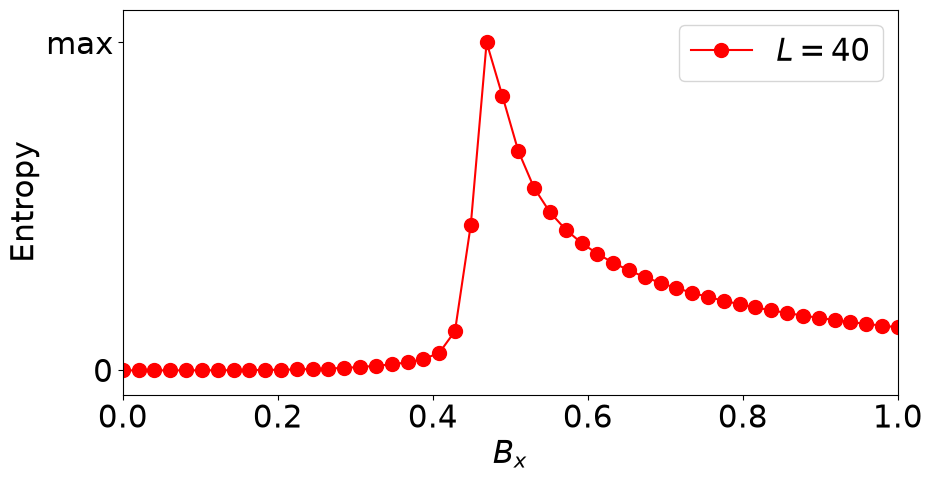

In [12]:
from dmrgpy import spinchain

def get_entropy(L=20,Bx=0.):
    spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = -1 # exchange
    for i in range(len(spins)-1): h = h + J*sc.Sz[i]*sc.Sz[i+1] # Ising coupling
    for i in range(L): h = h + Bx*sc.Sx[i] # transverse field
    sc.set_hamiltonian(-sum(sc.Sz)) ; wfguess = sc.get_gs(mode="DMRG") # get a full ferro state
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG",wf0=wfguess) # get ground state
    return wf0.get_bond_entropy(L//2,L//2+1)

plt.figure(figsize=(10,5))

Bxs = np.linspace(0.,1.,50,endpoint=True)
L = 40 # length of the system
ent = [get_entropy(L=L,Bx=Bx) for Bx in Bxs]
plt.plot(Bxs,ent,markersize=10,marker="o",label="$L = $"+str(L),c="red")
plt.xlabel("$B_x$") ; plt.ylabel("Entropy") ; plt.xlim([min(Bxs),max(Bxs)]) ; plt.ylim([-0.05,max(ent)*1.1])
plt.yticks(ticks=[0,max(ent)],labels=["0","max"])

plt.legend()

### Quiz
- Where do you think that the phase transition is in the thermodynamic limit?
- Why is the entanglement entropy small for small Bx and large Bx?
- Make the system smaller, what happens and why?
- Which region is the hardest to capture with matrix product states?

## Phase transition from the order parameter
We will now see how the same phase transition as above can be computed from the order parameter

Now we look at the same transition through the magnetization per site along $z$, $m = \frac{1}{L}\sum_n \langle S_n^z\rangle$, computed on the ground state for $B_x$ between $0$ and $J$ and for three chain lengths, $L=14$, $18$ and $22$. This is the order parameter of the ferromagnet, the quantity that is finite in the ordered phase and zero in the disordered one, so it is the conventional way of locating a phase transition, and here we can compare it with what the entanglement entropy told us without any order parameter. Look at where each curve drops and at how the drop depends on $L$.

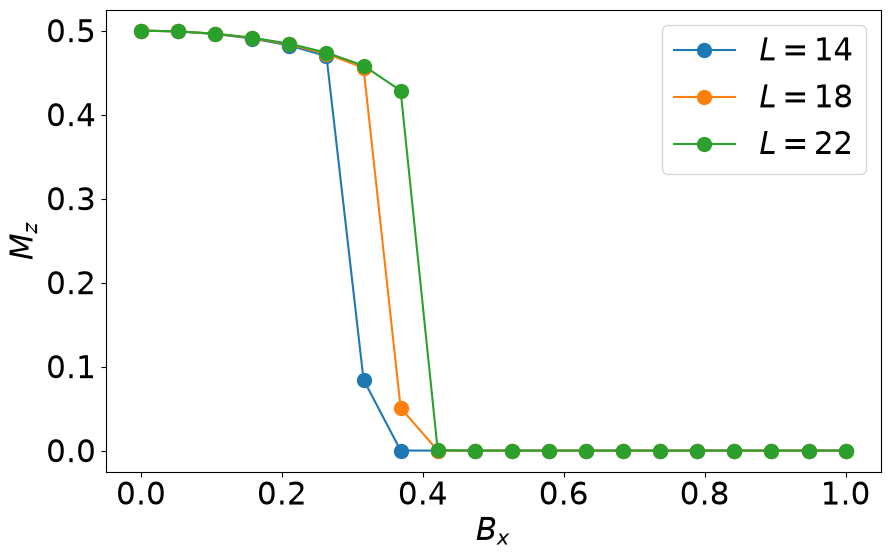

In [13]:
from dmrgpy import spinchain

def get_mz(L=20,Bx=0.):
    spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = -1. # exchange
    for i in range(len(spins)-1): h = h + J*sc.Sz[i]*sc.Sz[i+1] # Ising coupling
    for i in range(L): h = h + Bx*sc.Sx[i] # transverse field
    sc.set_hamiltonian(-sum(sc.Sz)) ; wfguess = sc.get_gs(mode="DMRG") # get a full ferro state
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG",wf0=wfguess) # get ground state, using wfguess as the guess
    return wf0.dot(sum(sc.Sz)*wf0).real/L # return magnetization

plt.figure(figsize=(10,6))

Bxs = np.linspace(0.,1.,20) # magnetic fields
Ls = [14,18,22] # lengths of the system

for L in Ls:
    mz = [get_mz(L=L,Bx=Bx) for Bx in Bxs]
    plt.plot(Bxs,mz,markersize=10,marker="o",label="$L = $"+str(L))
    plt.xlabel("$B_x$") ; plt.ylabel("$M_z$")

plt.legend()

### Quiz
- What is the ground state at each side of the transition?
- What would happen if you make the system bigger?
- Which is the hardest state to capture with matrix product states?

## Magnetization of moderately large Heisenberg model
Here we will show that a moderately large quantum Heisenberg model has zero magnetization

Here we repeat, for a chain of 50 spins, the calculation we did with exact diagonalization for ten spins in the second session: an antiferromagnetic Heisenberg chain with a very small uniform field $B_z = -0.01J$, and the ground state magnetization $\langle S^z_n\rangle$ plotted on every site. With ten spins one may wonder whether the small size is hiding something; with 50 spins, which is far beyond what exact diagonalization can reach, the question becomes whether the moderately large chain behaves in the same way. Look at the scale of the vertical axis.

(0.0, 49.0)

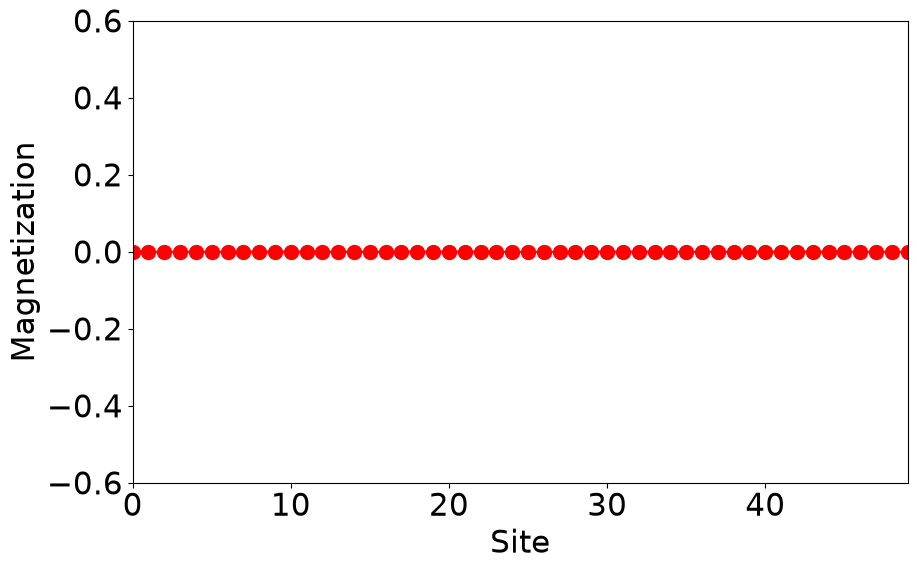

In [14]:
from dmrgpy import spinchain
n = 50 # number of sites
spins = ["S=1/2" for i in range(n)] # S=1/2 in each site
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
J = 1.0 # antiferromagnetic coupling, J=-1 for ferromagnetic coupling
Bz = -0.01 # small external magnetic field

for i in range(len(spins)-1): # Heisenberg coupling
    h = h + J*sc.Sx[i]*sc.Sx[i+1] ; h = h + J*sc.Sy[i]*sc.Sy[i+1] ; h = h + J*sc.Sz[i]*sc.Sz[i+1]
    
for i in range(len(spins)): h = h + Bz*sc.Sz[i] # and let's add a small magnetic field

plt.figure(figsize=(10,6))
sc.set_hamiltonian(h) # set the Hamiltonian
iis = range(n)
cs = [sc.vev(sc.Sz[i]) for i in iis] # compute the vacuum expectation value

plt.plot(iis,cs,marker="o",c="red",markersize=10)
plt.xlabel("Site") ; plt.ylabel("Magnetization") ; plt.ylim([-0.6,0.6]) ; plt.xlim([min(iis),max(iis)])

### Quiz
- Why is the magnetization zero everywhere even though there is a small external magnetic field?
- Make the value of the exchange negative, what happens and why?
- Take the case with antiferromagnetic coupling, and increase the value of the magnetic field. When do you get a finite magnetization and why?

## Magnetization of a large Heisenberg model with a magnetic impurity
Here we will now add a magnetic impurity to a quantum Heisenberg model, and see how the magnetization decays with distance

Here we put the local field $B_z = J$ on the first site of a Heisenberg chain of 40 spins, as we did for 14 spins with exact diagonalization, and we plot the magnetization $\langle S^z_n\rangle$ along the whole chain. The longer chain lets us follow the response to the impurity over many more sites before the other end is reached, which is what we need to tell how it decays with distance. Look at the sign from site to site and at the envelope of the profile: try plotting its absolute value on a logarithmic scale, and against the logarithm of the distance.

(0.0, 39.0)

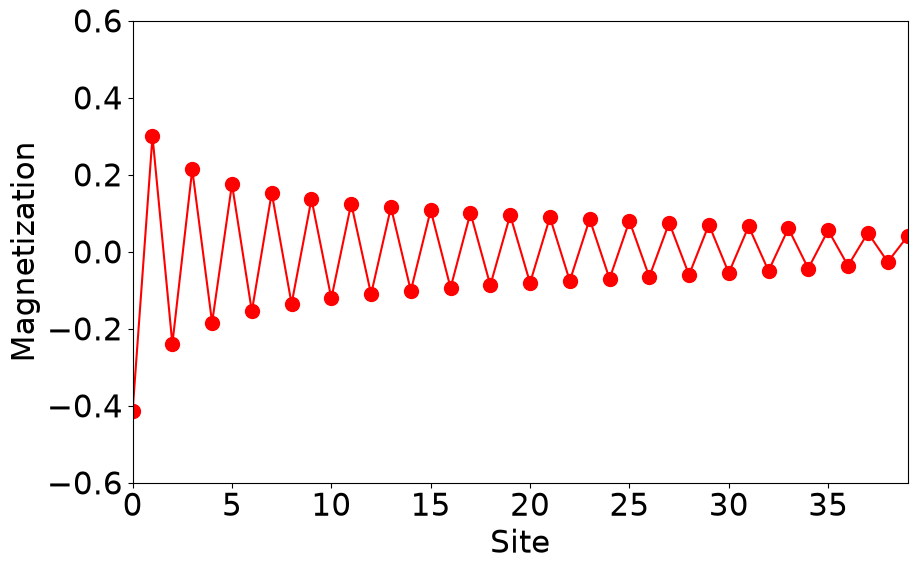

In [15]:
from dmrgpy import spinchain
n = 40 # length of the system
spins = ["S=1/2" for i in range(n)] # S=1/2 in each site
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
for i in range(len(spins)-1):
    h = h + sc.Sx[i]*sc.Sx[i+1]
    h = h + sc.Sy[i]*sc.Sy[i+1]
    h = h + sc.Sz[i]*sc.Sz[i+1]

    
Bz = 1. # strength of the local (impurity) field
h = h + Bz*sc.Sz[0]
    
sc.set_hamiltonian(h) # create the Hamiltonian
iis = range(n)
cs = [sc.vev(sc.Sz[i],mode="DMRG") for i in iis]

plt.figure(figsize=(10,6))
plt.plot(iis,cs,marker="o",c="red",markersize=10)
plt.xlabel("Site") ; plt.ylabel("Magnetization") ; plt.ylim([-0.6,0.6]) ; plt.xlim([min(iis),max(iis)])

### Quiz
- Why does the magnetization decay away from the magnetic site?
- Remove the XX and YY couplings. What happens and why?

## Magnetization of a dimerized Heisenberg model with a magnetic impurity
Here we will now add a magnetic impurity to a dimerized quantum Heisenberg model, and see how the magnetization decays with distance

Now we do the same with an alternating exchange, $J_n = J\left[1 + 0.2\,(-1)^n\right]$, so that strong and weak bonds alternate along the chain of 40 spins, keeping the same field $B_z = J$ on the first site. This is the dimerized chain we met in the second session, now at a size where the profile can be followed far from the impurity before the other edge matters. Compare with the uniform chain above, using the same logarithmic plots, and look at which of the two ways of plotting makes this profile a straight line.

(0.0, 39.0)

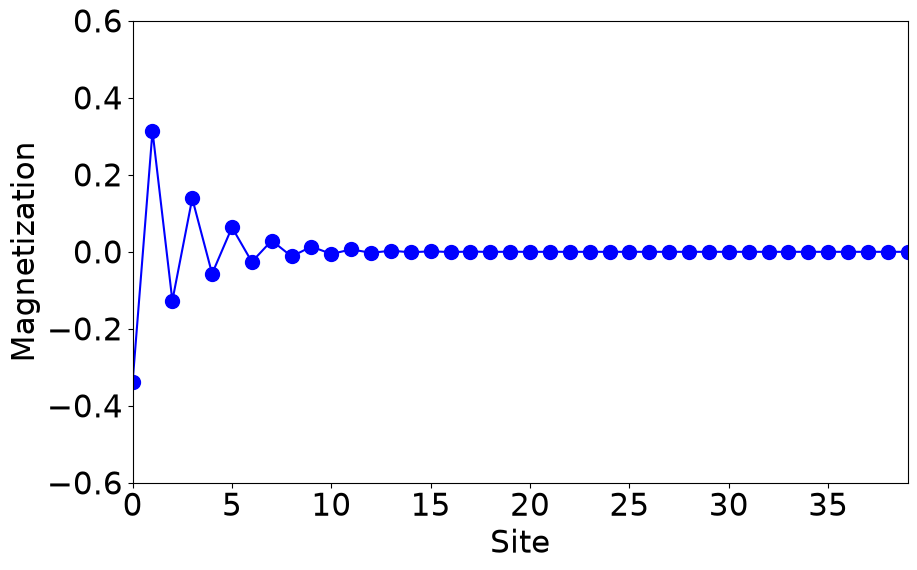

In [16]:
from dmrgpy import spinchain
n = 40 # length of the system
spins = ["S=1/2" for i in range(n)] # S=1/2 in each site
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
for i in range(len(spins)-1):
    J = 1.0 + .2*(-1)**i
    h = h + J*sc.Sx[i]*sc.Sx[i+1]
    h = h + J*sc.Sy[i]*sc.Sy[i+1]
    h = h + J*sc.Sz[i]*sc.Sz[i+1]

    
Bz = 1. # strength of the local (impurity) field
h = h + Bz*sc.Sz[0]
    
sc.set_hamiltonian(h) # create the Hamiltonian
iis = range(n)
cs = [sc.vev(sc.Sz[i],mode="DMRG") for i in iis]

plt.figure(figsize=(10,6))
plt.plot(iis,cs,marker="o",c="blue",markersize=10)
plt.xlabel("Site") ; plt.ylabel("Magnetization") ; plt.ylim([-0.6,0.6]) ; plt.xlim([min(iis),max(iis)])

### Quiz
- Why is the local magnetization decreasing?
- Why is the decrease much faster than the case above?
- Remove the XX and YY couplings. What happens and why?

## Magnetization of many-body excitations in large quantum chains
We will now see what is the magnetization profile of the excited states of a many-body spin chain

Here we take a chain of 40 spins with a small field $B_z=0.01J$ and a bond dimension $\chi=20$, we compute the four lowest eigenstates with DMRG, and for each of them we plot the magnetization profile $\langle S^z_n\rangle$ along the chain, with the energy measured from the ground state in the title of each panel. This is the calculation we did for ten spins in the second session, and the small field again splits states that would otherwise be degenerate. Look at which profiles are flat and which are not, and at where along the chain the others have their largest values.

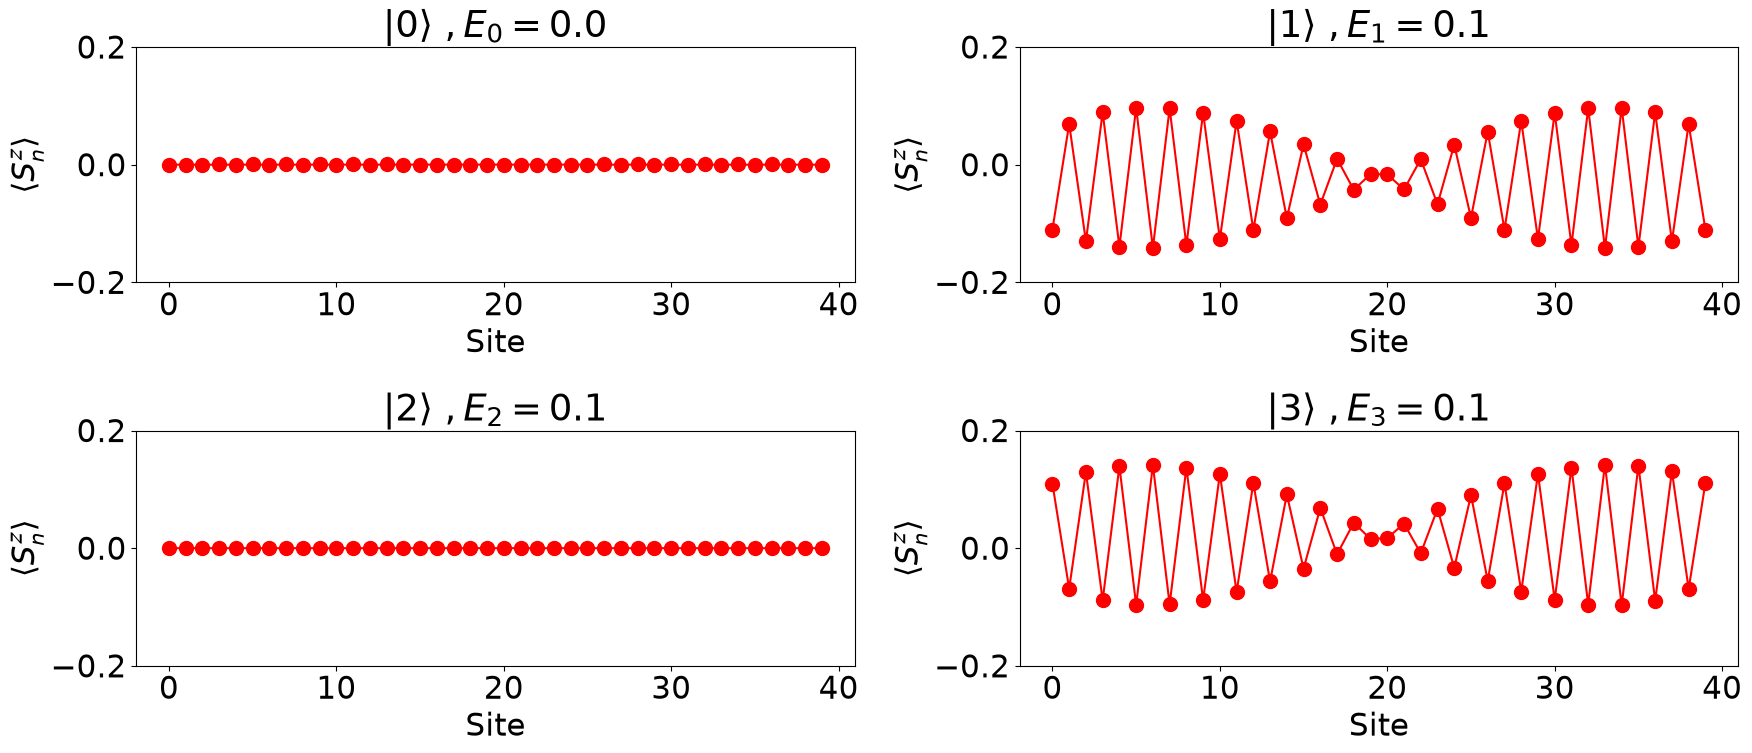

In [17]:
from dmrgpy import spinchain

L = 40 # number of spins

spins = ["S=1/2" for i in range(L)] # S=1/2 in each site
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
for i in range(len(spins)-1): # Heisenberg coupling
    h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
Bz = 0.01 # small magnetic field
h = h + Bz*sum(sc.Sz) # add external field
sc.maxm = 20 # modest bond dimension to accelerate the calculation
sc.set_hamiltonian(h) # set the Hamiltonian
nex = 4 # number of excited states
es,wfs = sc.get_excited_states(n=nex,mode="DMRG") # compute energies and excited states
es = es - es[0] # energy with respect to the ground state

plt.figure(figsize=(18,8))
ii = 1 # counter
for (e,wf) in zip(es,wfs): # loop
    plt.subplot(2,nex//2,ii) ; ii +=1 # subplot and increase
    mzs = [wf.dot(sz*wf) for sz in sc.Sz] # magnetization
    plt.plot(range(len(mzs)),mzs,marker="o",markersize=10,c="red") # plot
    plt.ylim([-0.2,0.2]) ; plt.ylabel("$\\langle S^z_n \\rangle$") ; plt.xlabel("Site")
    plt.title("$|$"+str(ii-2) + "$\\rangle$ $, E_"+str(ii-2)+" = $"+str(np.round(e,1)))
plt.tight_layout()

### Quiz
- Make the system smaller, what happens and why?
- Why are there two flat profiles?
- Why do states |1> and |3> have opposite profiles?

## Gap of a many-body spin chain
We will now see how the gap for a many-body spin chain scales with the system size, both for a pristine heisenberg model and a dimerized one

Here we compute the many-body gap $\Delta(L) = E_1(L) - E_0(L)$ for chains of $L=10$, $20$ and $30$ spins, both for the uniform Heisenberg chain and for the dimerized one with $\delta = 0.3$, using DMRG with a bond dimension $\chi=30$ to keep the calculation fast. In the second session we could only do this up to 14 spins, and the question of what the gap does for a long chain was left as an extrapolation. Look at the two curves, at the value each of them seems to approach, and think about the two impurity profiles above.

(0.0, 1.0)

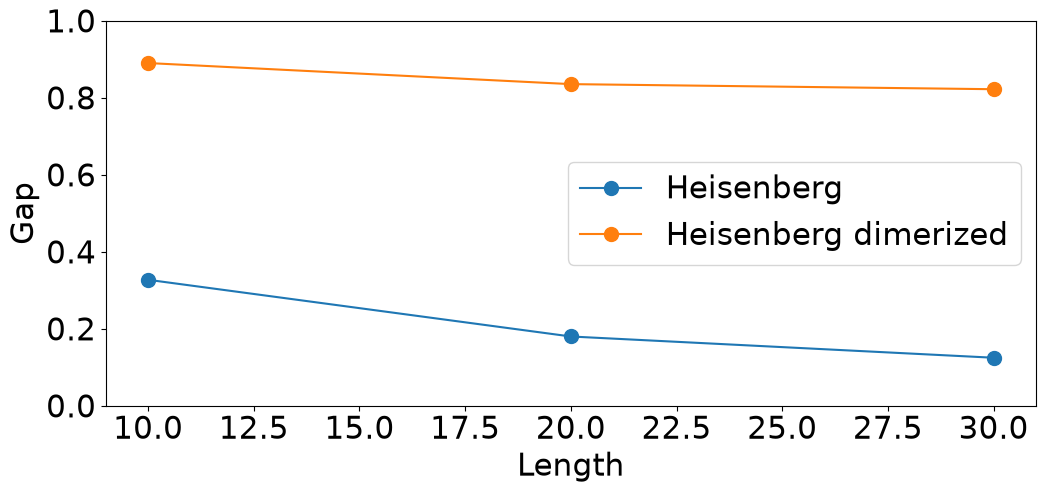

In [18]:
from dmrgpy import spinchain

def get_gap(n=20,dJ=0.):
    spins = ["S=1/2" for i in range(n)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1):
        J = 1.0 + dJ*(-1)**i
        h = h + J*sc.Sx[i]*sc.Sx[i+1] ; h = h + J*sc.Sy[i]*sc.Sy[i+1] ; h = h + J*sc.Sz[i]*sc.Sz[i+1]
    sc.maxm = 30 # to accelerate the calculation
    sc.set_hamiltonian(h) # create the Hamiltonian
    es = sc.get_excited(n=2,mode="DMRG") # get excited state energies
    g = es[1]-es[0] # energy to the first excited state
    return g # return the many-body gap

Ls = [10,20,30] # lengths of the system to consider
gaps = [get_gap(n=L,dJ=0.) for L in Ls] # gaps for the Heisenberg model
gaps_dim = [get_gap(n=L,dJ=0.3) for L in Ls] # gaps for the dimerized Heisenberg model

plt.figure(figsize=(12,5))
plt.plot(Ls,gaps,label="Heisenberg",marker="o",markersize=10)
plt.plot(Ls,gaps_dim,label="Heisenberg dimerized",marker="o",markersize=10)
plt.legend()
plt.xlabel("Length") ; plt.ylabel("Gap") ; plt.ylim([0.,1.0])

### Quiz
- What would be the gap in the limit of infinite length for both chains?
- What is the consequence in terms of how the magnetization around an impurity decreases as shown in the examples above?

## Non-local static correlators in a large system
We will now see how the non-local static correlators allow inferring which system has the strongest gap

Here we compute the spin correlator between the first site and every other site, $\langle \mathbf{S}_0\cdot\mathbf{S}_n\rangle$, in the ground state of a chain of 40 spins, for the uniform chain and for dimerizations $\delta = 0.2$ and $\delta=0.4$, and we plot the logarithm of its absolute value against the distance $n$. This is the correlator of the second session at four times the length, and on this scale a straight line means that the correlator decays exponentially, with a slope set by the correlation length. Look at the shape of each curve, and at whether all three are straight lines.

Text(0, 0.5, '$log|\\langle S_0^x S_N^x \\rangle |$')

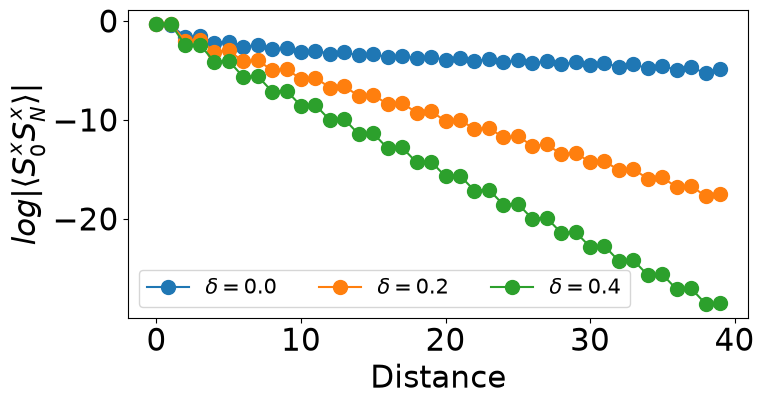

In [19]:
from dmrgpy import spinchain

def get_correlator(n=20,dJ=0.):
    spins = ["S=1/2" for i in range(n)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1):
        J = 1.0 + dJ*(-1)**i
        h = h + J*sc.Sx[i]*sc.Sx[i+1] ; h = h + J*sc.Sy[i]*sc.Sy[i+1] ; h = h + J*sc.Sz[i]*sc.Sz[i+1]
    sc.set_hamiltonian(h) # create the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG") # compute ground state
    return [3*wf0.dot((sc.Sx[0]*sc.Sx[i])*wf0).real for i in range(n)]

plt.figure(figsize=(8,4))

dJs = [0.,0.2,0.4] # dimerizations
for dJ in dJs:
    cij = get_correlator(n=40,dJ=dJ)
    plt.plot(range(len(cij)),np.log(np.abs(cij)),label="$\\delta =$"+str(dJ),marker="o",markersize=10)

plt.legend(ncol=len(dJs),fontsize=15)
plt.xlabel("Distance") ; plt.ylabel("$log|\\langle S_0^x S_N^x \\rangle |$") 

### Quiz
- Which parameter would lead to the biggest gap in the thermodynamic limit?
- Make the system bigger, what do you observe?
- How can you know if some of the systems will be gapless in the thermodynamic limit?

## Fractionalization in the S=1 Heisenberg model
We will now see how the S=1 Heisenberg model features fractional topological edge modes

Here we replace the spin-$1/2$ chain by a chain of 40 spins with $S=1$, three states per site instead of two, keeping the antiferromagnetic Heisenberg coupling, we add a uniform field $B_z = 0.2J$ pointing along $z$, and we plot the ground state magnetization $\langle S^z_n\rangle$ on every site. The title of the plot gives the total magnetization of the left half and of the right half of the chain. Look at where along the chain the magnetization sits, at its sign on each side, and at the two numbers in the title.

(0.0, 39.0)

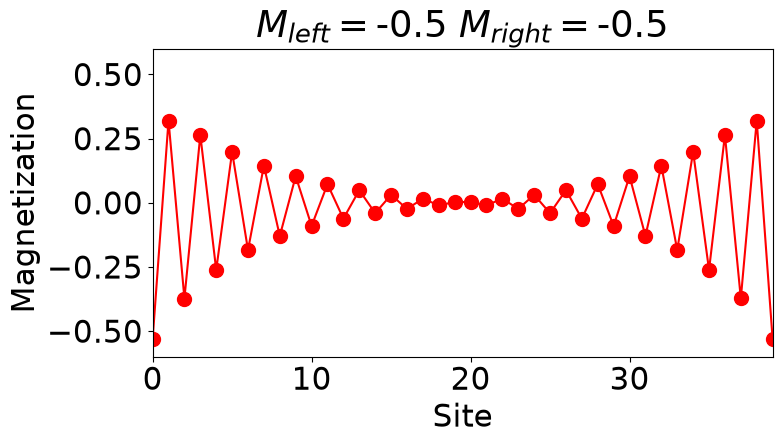

In [20]:
from dmrgpy import spinchain
n = 40 # length of the system
spins = ["S=1" for i in range(n)] # S=1 in each site
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
J = 1.0
for i in range(len(spins)-1):
    h = h + J*sc.Sx[i]*sc.Sx[i+1]
    h = h + J*sc.Sy[i]*sc.Sy[i+1]
    h = h + J*sc.Sz[i]*sc.Sz[i+1]

Bz = 0.2 # uniform magnetic field strength
h = h + Bz*sum(sc.Sz) # add a magnetic field everywhere
    
sc.set_hamiltonian(h) # create the Hamiltonian
iis = range(n) # indexes
Mzs = [sc.vev(sc.Sz[i],mode="DMRG").real for i in iis] # local magnetization

fig = plt.figure(figsize=(8,4))
Ml = sum([Mzs[i] for i in range(0,n//2)]) # left magnetization
Mr = sum([Mzs[i] for i in range(n//2,n)]) # right magnetization
plt.title("$M_{left}  = $"+str(np.round(Ml,1)) + " $M_{right}  = $"+str(np.round(Mr,1)))
plt.plot(iis,Mzs,marker="o",c="red",markersize=10)
plt.xlabel("Site") ; plt.ylabel("Magnetization") ; plt.ylim([-0.6,0.6]) ; plt.xlim([min(iis),max(iis)])

### Quiz
- What happens if you make the system smaller, and why?
- What happens if you make the system bigger, and why?
- What do you expect to be the degeneracy of the ground state in the thermodynamic limit?

## Non-local correlator in the S=1/2 and S=1 Heisenberg models
Let us now compare the spin correlators of the spin-1/2 and the spin-1 Heisenberg chains

Here we compute the spin correlator $\langle \mathbf{S}_1\cdot\mathbf{S}_n\rangle$ between the first bulk site and every other site, for a chain of 40 spins with $S=1/2$ and for one with $S=1$, and we plot the logarithm of its absolute value against the distance. In both cases the code adds an extra spin-$1/2$ at each end of the chain, coupled with the same $J$, and the correlator is measured from the first site after it. Compare the two curves with the ones of the previous exercise, and look at which of them is a straight line.

Text(0, 0.5, '$log|\\langle S_0^x S_N^x \\rangle |$')

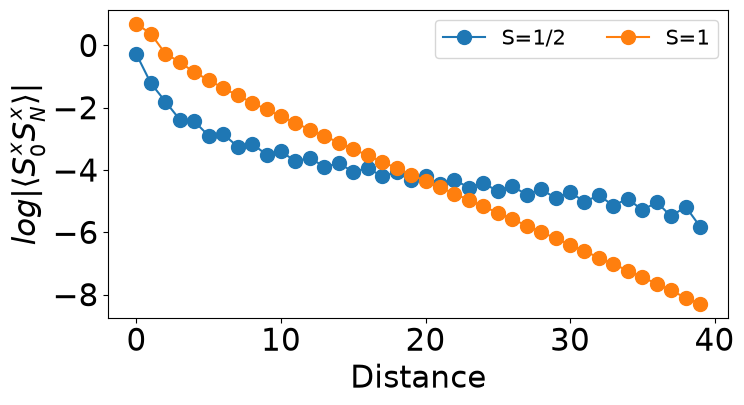

In [21]:
from dmrgpy import spinchain

def get_correlator(n=10,S="S=1/2"):
    spins = ["S=1/2"] + [S for i in range(n)] + ["S=1/2"] # S chain with S=1/2 at the edges
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1):
        J = 1.0 
        h = h + J*sc.Sx[i]*sc.Sx[i+1] ; h = h + J*sc.Sy[i]*sc.Sy[i+1] ; h = h + J*sc.Sz[i]*sc.Sz[i+1]
    sc.set_hamiltonian(h) # create the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG") # compute ground state
    return [3*wf0.dot((sc.Sx[1]*sc.Sx[i])*wf0).real for i in range(1,n+1)] # compute correlator

plt.figure(figsize=(8,4))

Ss = ["S=1/2","S=1"] # different spins
for S in Ss:
    cij = get_correlator(n=40,S=S)
    plt.plot(range(len(cij)),np.log(np.abs(cij)),label=S,marker="o",markersize=10)

plt.legend(ncol=len(Ss),fontsize=15)
plt.xlabel("Distance") ; plt.ylabel("$log|\\langle S_0^x S_N^x \\rangle |$") 

### Quiz
- What is the biggest system size that you could have done with exact diagonalization?
- Why have we included a S=1/2 at the beginning and end of the chain for S=1?
- What does it mean that the correlator decays exponentially?